# 03 — TorchAO CPU INT8 PTQ

Notes:
- `backend='torchao_cpu_ptq'`, `device='cpu'`, `model_precision='int8'`.
- calib on `val` set


In [1]:
from pathlib import Path
import sys, os

# ---- Path setup (adjust if your repo layout differs) ----
PROJECT_ROOT = Path("..").resolve()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [2]:
%load_ext autoreload
%autoreload 2

import torch
import pandas as pd

from config import ExperimentConfig, with_overrides
from runner import run_experiment

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


In [3]:
# ---- Base config (edit imagenet_path once, keep deterministic) ----
base_cpu = ExperimentConfig(
    
    device="cpu",
    batch_size=256,
    num_workers=8,
    seed=42,
    num_eval_batches=None,
    input_quant_bits=8,
    backend="torchao_cpu_ptq",
    model_precision="int8",
    cpu_calib_num_batches=10,
)

base_cpu.validate()
print("run root:", base_cpu.output_root)


run root: ./runs


In [4]:

cfg = with_overrides(base_cpu, num_eval_batches=10)
payload, _ = run_experiment(cfg, split="val", save_results_flag=True)
payload["results"]


/home/pf4636/code/resnet/quantized_resnets/.venv/lib/python3.12/site-packages/torchao/quantization/pt2e/quantizer/x86_inductor_quantizer.py:1325: UserWarning: The input of maxpool2d is not quantized, skip annotate maxpool2d with config QuantizationConfig(input_activation=QuantizationSpec(dtype=torch.uint8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.HistogramObserver'>, eps=0.000244140625){}, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine, ch_axis=None, is_dynamic=False), output_activation=QuantizationSpec(dtype=torch.uint8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.HistogramObserver'>, eps=0.000244140625){}, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine, ch_axis=None, is_dynamic=False), weight=QuantizationSpec(dtype=torch.int8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.PerChannelMinMaxObserver'>, eps=0.000244140625){}, quant

Evaluating on 10 batches...
  Batch [10/10] Top-1: 78.52% | Top-5: 93.16% | Infer: 1551.90 ms/batch
[saved] runs/resnet18_torchao_cpu_ptq_int8_in8b_cpu_bs256/result.json


{'top1_acc': 78.515625,
 'top5_acc': 93.1640625,
 'loss_avg': 0.8500139147043229,
 'batch_ms_avg': 1553.3565473975614,
 'infer_ms_avg': 1551.8972695979755,
 'infer_ms_std': 108.28179672921777,
 'throughput_infer_sps': 164.95937264347253,
 'throughput_sps': 164.8044040042792,
 'total_samples': 2560,
 'total_batches': 10}

In [5]:
# Full run
cfg = base_cpu
payload, _ = run_experiment(cfg, split="val", save_results_flag=True)
payload["results"]


/home/pf4636/code/resnet/quantized_resnets/.venv/lib/python3.12/site-packages/torchao/quantization/pt2e/quantizer/x86_inductor_quantizer.py:1325: UserWarning: The input of maxpool2d is not quantized, skip annotate maxpool2d with config QuantizationConfig(input_activation=QuantizationSpec(dtype=torch.uint8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.HistogramObserver'>, eps=0.000244140625){}, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine, ch_axis=None, is_dynamic=False), output_activation=QuantizationSpec(dtype=torch.uint8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.HistogramObserver'>, eps=0.000244140625){}, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine, ch_axis=None, is_dynamic=False), weight=QuantizationSpec(dtype=torch.int8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.PerChannelMinMaxObserver'>, eps=0.000244140625){}, quant

Evaluating on 195 batches...
  Batch [10/195] Top-1: 78.52% | Top-5: 93.16% | Infer: 1487.23 ms/batch
  Batch [20/195] Top-1: 76.66% | Top-5: 92.68% | Infer: 1458.70 ms/batch
  Batch [30/195] Top-1: 77.93% | Top-5: 92.85% | Infer: 1461.03 ms/batch
  Batch [40/195] Top-1: 76.23% | Top-5: 92.95% | Infer: 1460.49 ms/batch
  Batch [50/195] Top-1: 75.80% | Top-5: 93.20% | Infer: 1491.84 ms/batch
  Batch [60/195] Top-1: 75.70% | Top-5: 93.38% | Infer: 1491.24 ms/batch
  Batch [70/195] Top-1: 76.21% | Top-5: 93.53% | Infer: 1492.91 ms/batch
  Batch [80/195] Top-1: 76.14% | Top-5: 93.37% | Infer: 1492.44 ms/batch
  Batch [90/195] Top-1: 74.97% | Top-5: 92.59% | Infer: 1491.53 ms/batch
  Batch [100/195] Top-1: 73.58% | Top-5: 91.71% | Infer: 1491.98 ms/batch
  Batch [110/195] Top-1: 72.93% | Top-5: 91.26% | Infer: 1493.91 ms/batch
  Batch [120/195] Top-1: 72.68% | Top-5: 90.92% | Infer: 1493.04 ms/batch
  Batch [130/195] Top-1: 71.64% | Top-5: 90.37% | Infer: 1493.01 ms/batch
  Batch [140/195] 

{'top1_acc': 69.8016826923077,
 'top5_acc': 89.1005608974359,
 'loss_avg': 1.2450513743437253,
 'batch_ms_avg': 1482.3564058217482,
 'infer_ms_avg': 1481.596101287048,
 'infer_ms_std': 72.1597421100773,
 'throughput_infer_sps': 172.78663178015609,
 'throughput_sps': 172.69800905814262,
 'total_samples': 49920,
 'total_batches': 195}

Evaluating on 50 batches...
  Batch [10/50] Top-1: 78.52% | Top-5: 93.16% | Infer: 1679.47 ms/batch
  Batch [20/50] Top-1: 76.66% | Top-5: 92.68% | Infer: 1642.79 ms/batch
  Batch [30/50] Top-1: 77.93% | Top-5: 92.85% | Infer: 1651.48 ms/batch
  Batch [40/50] Top-1: 76.23% | Top-5: 92.95% | Infer: 1661.41 ms/batch
  Batch [50/50] Top-1: 75.80% | Top-5: 93.20% | Infer: 1665.82 ms/batch


/home/pf4636/code/resnet/quantized_resnets/.venv/lib/python3.12/site-packages/torchao/quantization/pt2e/quantizer/x86_inductor_quantizer.py:1325: UserWarning: The input of maxpool2d is not quantized, skip annotate maxpool2d with config QuantizationConfig(input_activation=QuantizationSpec(dtype=torch.uint8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.HistogramObserver'>, eps=0.000244140625){}, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine, ch_axis=None, is_dynamic=False), output_activation=QuantizationSpec(dtype=torch.uint8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.HistogramObserver'>, eps=0.000244140625){}, quant_min=0, quant_max=255, qscheme=torch.per_tensor_affine, ch_axis=None, is_dynamic=False), weight=QuantizationSpec(dtype=torch.int8, observer_or_fake_quant_ctr=functools.partial(<class 'torchao.quantization.pt2e.observer.PerChannelMinMaxObserver'>, eps=0.000244140625){}, quant

Evaluating on 50 batches...
  Batch [10/50] Top-1: 78.52% | Top-5: 93.16% | Infer: 1497.38 ms/batch
  Batch [20/50] Top-1: 76.66% | Top-5: 92.68% | Infer: 1453.82 ms/batch
  Batch [30/50] Top-1: 77.93% | Top-5: 92.85% | Infer: 1443.54 ms/batch
  Batch [40/50] Top-1: 76.23% | Top-5: 92.95% | Infer: 1442.11 ms/batch
  Batch [50/50] Top-1: 75.80% | Top-5: 93.20% | Infer: 1443.81 ms/batch


,run_id,backend,precision,device,input_quant_bits,batch_size,top1_acc,top5_acc,infer_ms_avg,infer_ms_std,infer_ms_per_image,throughput_infer_sps,throughput_sps,total_batches,total_samples
tag,,,,,,,,,,,,,,,
cpu_fp32_quick,resnet18_pytorch_fp32_in8b_cpu_bs256,pytorch,fp32,cpu,8,256,75.796875,93.203125,1665.824969,71.262966,6.507129,153.677610,153.606102,50,12800
cpu_int8_ptq_quick,resnet18_torchao_cpu_ptq_int8_in8b_cpu_bs256,torchao_cpu_ptq,int8,cpu,8,256,75.796875,93.203125,1443.814044,50.579640,5.639899,177.308152,177.222200,50,12800
cpu_int8_ptq_full,resnet18_torchao_cpu_ptq_int8_in8b_cpu_bs256,torchao_cpu_ptq,int8,cpu,8,256,69.801683,89.100561,1481.596101,72.159742,5.787485,172.786632,172.698009,195,49920


NameError: name 'save_current_plot' is not defined

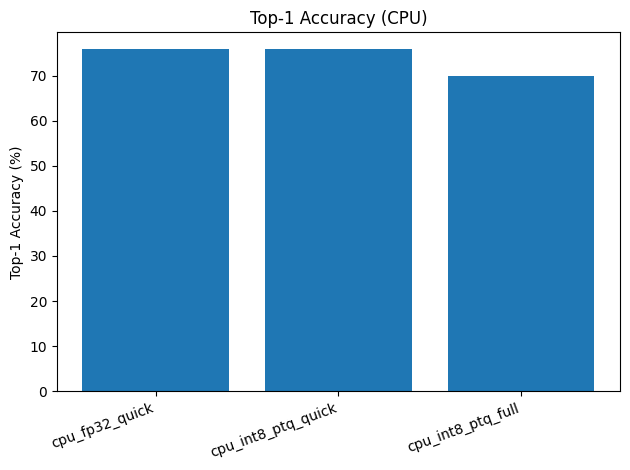

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# How many batches to run for the curves (keeps plots snappy).
# Set to None if you really want full-val curves (will be long).
PLOT_EVAL_BATCHES = 50

# Reuse base_cpu from earlier cell
cfg_plot = with_overrides(base_cpu, num_eval_batches=PLOT_EVAL_BATCHES)

# Baseline (PyTorch FP32 on CPU) + INT8 PTQ (TorchAO CPU)
cfg_fp32 = with_overrides(cfg_plot, backend="pytorch", model_precision="fp32")
cfg_int8 = with_overrides(cfg_plot, backend="torchao_cpu_ptq", model_precision="int8")

payload_fp32, tracker_fp32 = run_experiment(cfg_fp32, split="val", save_results_flag=False)
payload_int8, tracker_int8 = run_experiment(cfg_int8, split="val", save_results_flag=False)

# ---- Summary table (quick-run) + optionally include your full-run payload if it exists ----
rows = []
def _row_from_payload(tag, pl):
    r = dict(pl.get("results", {}))
    cfg = pl.get("config", {})
    bs = cfg.get("batch_size", None)
    infer_ms_avg = r.get("infer_ms_avg", None)
    r.update({
        "tag": tag,
        "run_id": pl.get("run_id", ""),
        "backend": cfg.get("backend", ""),
        "precision": cfg.get("model_precision", ""),
        "device": cfg.get("device", ""),
        "input_quant_bits": cfg.get("input_quant_bits", None),
        "batch_size": bs,
        "infer_ms_per_image": (infer_ms_avg / bs) if (infer_ms_avg is not None and bs) else None,
    })
    return r

rows.append(_row_from_payload("cpu_fp32_quick", payload_fp32))
rows.append(_row_from_payload("cpu_int8_ptq_quick", payload_int8))

# If you ran a full INT8 run above and still have `payload` in scope, include it too
try:
    if isinstance(payload, dict) and payload.get("results"):
        rows.append(_row_from_payload("cpu_int8_ptq_full", payload))
except NameError:
    pass

df = pd.DataFrame(rows).set_index("tag")
display(df[[
    "run_id", "backend", "precision", "device", "input_quant_bits", "batch_size",
    "top1_acc", "top5_acc", "infer_ms_avg", "infer_ms_std", "infer_ms_per_image",
    "throughput_infer_sps", "throughput_sps", "total_batches", "total_samples"
]])

# ---- Bar plots: accuracy + latency (per image) ----
labels = list(df.index)
x = np.arange(len(labels))

# Top-1
plt.figure()
plt.bar(x, df["top1_acc"].astype(float))
plt.xticks(x, labels, rotation=20, ha="right")
plt.ylabel("Top-1 Accuracy (%)")
plt.title("Top-1 Accuracy (CPU)")
plt.tight_layout()
save_current_plot(
    out_dir=Path("runs") / "plots" / cfg_int8.run_id(),
    formats=("png", "pdf"),
    metadata={"run_id": cfg_int8.run_id(), "backend": cfg_int8.backend, "precision": cfg_int8.model_precision},
)
plt.show()

# Top-5
plt.figure()
plt.bar(x, df["top5_acc"].astype(float))
plt.xticks(x, labels, rotation=20, ha="right")
plt.ylabel("Top-5 Accuracy (%)")
plt.title("Top-5 Accuracy (CPU)")
plt.tight_layout()
save_current_plot(
    out_dir=Path("runs") / "plots" / cfg_int8.run_id(),
    formats=("png", "pdf"),
    metadata={"run_id": cfg_int8.run_id(), "backend": cfg_int8.backend, "precision": cfg_int8.model_precision},
)
plt.show()

# Infer time per image (ms)
if df["infer_ms_per_image"].notna().any():
    plt.figure()
    plt.bar(x, df["infer_ms_per_image"].astype(float))
    plt.xticks(x, labels, rotation=20, ha="right")
    plt.ylabel("Infer time (ms / image)")
    plt.title("Inference latency (per image, derived from ms/batch ÷ batch_size)")
    plt.tight_layout()
    save_current_plot(
    out_dir=Path("runs") / "plots" / cfg_int8.run_id(),
    formats=("png", "pdf"),
    metadata={"run_id": cfg_int8.run_id(), "backend": cfg_int8.backend, "precision": cfg_int8.model_precision},
)
    plt.show()

# ---- Per-batch curves (quick-run trackers) ----
def _plot_running_acc(tracker, label, which="top1"):
    if tracker is None:
        return
    y = tracker.top1_running if which == "top1" else tracker.top5_running
    xs = np.arange(1, len(y) + 1)
    plt.plot(xs, y, label=label)

plt.figure()
_plot_running_acc(tracker_fp32, "cpu_fp32_quick", which="top1")
_plot_running_acc(tracker_int8, "cpu_int8_ptq_quick", which="top1")
plt.xlabel("Batch")
plt.ylabel("Running Top-1 (%)")
plt.title("Running Top-1 over batches (quick run)")
plt.legend()
plt.tight_layout()
save_current_plot(
    out_dir=Path("runs") / "plots" / cfg_int8.run_id(),
    formats=("png", "pdf"),
    metadata={"run_id": cfg_int8.run_id(), "backend": cfg_int8.backend, "precision": cfg_int8.model_precision},
)
plt.show()

plt.figure()
_plot_running_acc(tracker_fp32, "cpu_fp32_quick", which="top5")
_plot_running_acc(tracker_int8, "cpu_int8_ptq_quick", which="top5")
plt.xlabel("Batch")
plt.ylabel("Running Top-5 (%)")
plt.title("Running Top-5 over batches (quick run)")
plt.legend()
plt.tight_layout()
save_current_plot(
    out_dir=Path("runs") / "plots" / cfg_int8.run_id(),
    formats=("png", "pdf"),
    metadata={"run_id": cfg_int8.run_id(), "backend": cfg_int8.backend, "precision": cfg_int8.model_precision},
)
plt.show()

# Per-batch inference time (ms/batch)
def _infer_ms_list(tracker):
    if tracker is None:
        return None
    return np.asarray(tracker.infer_times_s, dtype=np.float64) * 1000.0

infer_fp32 = _infer_ms_list(tracker_fp32)
infer_int8 = _infer_ms_list(tracker_int8)

plt.figure()
if infer_fp32 is not None:
    plt.plot(np.arange(1, len(infer_fp32) + 1), infer_fp32, label="cpu_fp32_quick")
if infer_int8 is not None:
    plt.plot(np.arange(1, len(infer_int8) + 1), infer_int8, label="cpu_int8_ptq_quick")
plt.xlabel("Batch")
plt.ylabel("Infer time (ms / batch)")
plt.title("Per-batch forward-pass time (quick run)")
plt.legend()
plt.tight_layout()
save_current_plot(
    out_dir=Path("runs") / "plots" / cfg_int8.run_id(),
    formats=("png", "pdf"),
    metadata={"run_id": cfg_int8.run_id(), "backend": cfg_int8.backend, "precision": cfg_int8.model_precision},
)
plt.show()

# Histogram of per-batch inference time (optional, quick feel for variance)
plt.figure()
if infer_fp32 is not None:
    plt.hist(infer_fp32, bins=30, alpha=0.6, label="cpu_fp32_quick")
if infer_int8 is not None:
    plt.hist(infer_int8, bins=30, alpha=0.6, label="cpu_int8_ptq_quick")
plt.xlabel("Infer time (ms / batch)")
plt.ylabel("Count")
plt.title("Distribution of per-batch infer times (quick run)")
plt.legend()
plt.tight_layout()
save_current_plot(
    out_dir=Path("runs") / "plots" / cfg_int8.run_id(),
    formats=("png", "pdf"),
    metadata={"run_id": cfg_int8.run_id(), "backend": cfg_int8.backend, "precision": cfg_int8.model_precision},
)
plt.show()
